#  Porter Delivery Time Estimation: Neural Network Regression

## Problem Statement
Porter is India's largest marketplace for intra-city logistics, operating in the $40 billion intra-city logistics market. They work with restaurants to deliver food items to customers and want to provide **accurate delivery time estimates** at the point of ordering.

**Goal:** Build a Neural Network regression model that predicts the **delivery time (in minutes)** based on features such as order details, restaurant category, delivery partner availability, and estimated driving duration.

**Dataset:** Each row = one unique delivery order  
**Target Variable:** Delivery time in minutes (derived from `created_at` and `actual_delivery_time`)

##  Step 1: Install & Import Libraries

In [ ]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('NumPy  :', np.__version__)
print('Pandas :', pd.__version__)
print('TF     :', tf.__version__)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

NumPy  : 2.1.3
Pandas : 2.2.3
TF     : 2.20.0


##  Step 2: Load Data & Initial Structure Analysis

In [ ]:
df = pd.read_csv('/content/data_2.csv')   # change path if needed

print('Shape:', df.shape)
df.head()

Shape: (175777, 14)


,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [ ]:
# Column names & dtypes
print('\n Column Info ')
df.info()


 Column Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                   

In [ ]:
# Descriptive statistics
print('\n Descriptive Statistics ')
df.describe(include='all')


 Descriptive Statistics 


,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
count,175777.000000,175777,175777,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000,175777.000000
unique,NaN,162649,160344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2015-02-11 19:50:43,2015-02-15 04:18:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.743726,NaN,NaN,35.887949,2.911752,3.204976,2697.111147,2.675060,684.965433,1160.158616,44.918664,41.861381,58.230115,546.077240
std,1.330963,NaN,NaN,20.728254,1.513128,2.674055,1828.554893,1.625681,519.882924,560.828571,34.544724,32.168505,52.731043,218.717798
min,1.000000,NaN,NaN,0.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000
25%,2.000000,NaN,NaN,18.000000,1.000000,2.000000,1412.000000,1.000000,299.000000,799.000000,17.000000,15.000000,17.000000,384.000000
50%,2.000000,NaN,NaN,38.000000,3.000000,3.000000,2224.000000,2.000000,595.000000,1095.000000,37.000000,35.000000,41.000000,544.000000
75%,4.000000,NaN,NaN,55.000000,4.000000,4.000000,3410.000000,3.000000,942.000000,1395.000000,66.000000,63.000000,85.000000,703.000000


In [ ]:
# Missing values
df.isnull().sum()


,0
market_id,0
created_at,0
actual_delivery_time,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0


In [ ]:
# Duplicate rows check
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


##  Step 3: Data Preprocessing & Feature Engineering

### 3.1 Parse Timestamps & Create Target Variable

In [ ]:
# Parse datetime columns
df['created_at']            = pd.to_datetime(df['created_at'])
df['actual_delivery_time']  = pd.to_datetime(df['actual_delivery_time'])

# ── Target: delivery time in MINUTES ─────────────────────────────────────────
df['delivery_time_min'] = (
    (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60
)

print('Delivery time (minutes) — sample values:')
print(df['delivery_time_min'].describe())

Delivery time (minutes) — sample values:
count    175777.000000
mean         46.203013
std           9.327424
min          32.000000
25%          39.000000
50%          45.000000
75%          52.000000
max         110.000000
Name: delivery_time_min, dtype: float64


In [ ]:
# Drop rows where delivery time is non-positive (data error)
before = len(df)
df = df[df['delivery_time_min'] > 0].copy()
print(f'Rows removed (delivery_time_min <= 0): {before - len(df)}')

Rows removed (delivery_time_min <= 0): 0


### 3.2 Extract Time-Based Features (Hour of Day & Day of Week)

In [ ]:
# Hour of day the order was placed (0–23)
df['order_hour']       = df['created_at'].dt.hour

# Day of week (0 = Monday … 6 = Sunday)
df['order_day_of_week'] = df['created_at'].dt.dayofweek



print(df[['created_at','order_hour','order_day_of_week','delivery_time_min']].head(10))

           created_at  order_hour  order_day_of_week  delivery_time_min
0 2015-02-06 22:24:17          22                  4               47.0
1 2015-02-10 21:49:25          21                  1               44.0
2 2015-02-16 00:11:35           0                  0               55.0
3 2015-02-12 03:36:46           3                  3               59.0
4 2015-01-27 02:12:36           2                  1               46.0
5 2015-02-06 00:42:42           0                  4               56.0
6 2015-02-08 02:04:17           2                  6               63.0
7 2015-01-31 04:35:54           4                  5               58.0
8 2015-01-31 02:21:23           2                  5               37.0
9 2015-01-31 23:45:12          23                  5               41.0


### 3.3 Handle Null Values

In [ ]:
# Identify columns still with nulls after datetime parsing
null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0]
print('Columns with nulls:\n', null_cols)

# Strategy:
#  - Numeric columns  → fill with MEDIAN (robust to outliers)
#  - Categorical cols → fill with MODE

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols     = df.select_dtypes(include=['object','category']).columns.tolist()

# Exclude timestamp & target from null-fill loop
exclude = ['created_at','actual_delivery_time','delivery_time_min']

for col in numeric_cols:
    if col not in exclude and df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Filled numeric  "{col}" with median = {median_val:.2f}')

for col in cat_cols:
    if col not in exclude and df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  Filled category "{col}" with mode  = {mode_val}')

print('\nNull values remaining:', df.isnull().sum().sum())

Columns with nulls:
 Series([], dtype: int64)

Null values remaining: 0


### 3.4 Encode Categorical Columns

In [ ]:
# store_primary_category may be numeric-coded already or string; check
print('store_primary_category dtype:', df['store_primary_category'].dtype)
print('Unique values (first 10):', df['store_primary_category'].unique()[:10])

store_primary_category dtype: int64
Unique values (first 10): [ 4 46 36 38 58 68 15 57 55 20]


In [ ]:
# If store_primary_category is numeric, treat as integer category and keep as-is.
# If it contains strings, apply Label Encoding.

if df['store_primary_category'].dtype == object:
    le = LabelEncoder()
    df['store_primary_category'] = le.fit_transform(df['store_primary_category'].astype(str))
    print('Label Encoding applied. Unique encoded values:', df['store_primary_category'].nunique())
else:
    # Already numeric; just ensure integer type
    df['store_primary_category'] = df['store_primary_category'].astype(int)
    print('store_primary_category is already numeric. Unique values:', df['store_primary_category'].nunique())

# market_id is a categorical integer identifier — keep as-is
# order_protocol is an integer code — keep as-is

print('\nFinal dtypes:\n', df.dtypes)

store_primary_category is already numeric. Unique values: 73

Final dtypes:
 market_id                                              float64
created_at                                      datetime64[ns]
actual_delivery_time                            datetime64[ns]
store_primary_category                                   int64
order_protocol                                         float64
total_items                                              int64
subtotal                                                 int64
num_distinct_items                                       int64
min_item_price                                           int64
max_item_price                                           int64
total_onshift_dashers                                  float64
total_busy_dashers                                     float64
total_outstanding_orders                               float64
estimated_store_to_consumer_driving_duration           float64
delivery_time_min                        

## Step 4: Data Visualization & Cleaning

### 4.1 Distribution of Target Variable

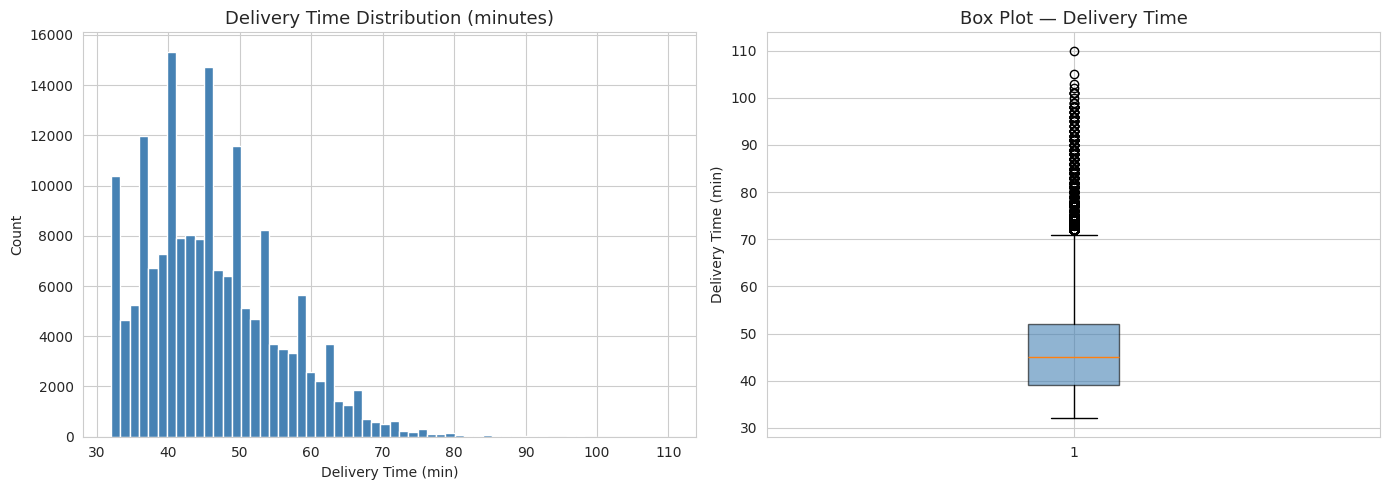

count    175777.000000
mean         46.203013
std           9.327424
min          32.000000
25%          39.000000
50%          45.000000
75%          52.000000
max         110.000000
Name: delivery_time_min, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['delivery_time_min'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Delivery Time Distribution (minutes)', fontsize=13)
axes[0].set_xlabel('Delivery Time (min)')
axes[0].set_ylabel('Count')

# Box plot
axes[1].boxplot(df['delivery_time_min'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot — Delivery Time', fontsize=13)
axes[1].set_ylabel('Delivery Time (min)')

plt.tight_layout()
plt.show()

print(df['delivery_time_min'].describe())

### 4.2 Count Plots : Categorical / Discrete Features

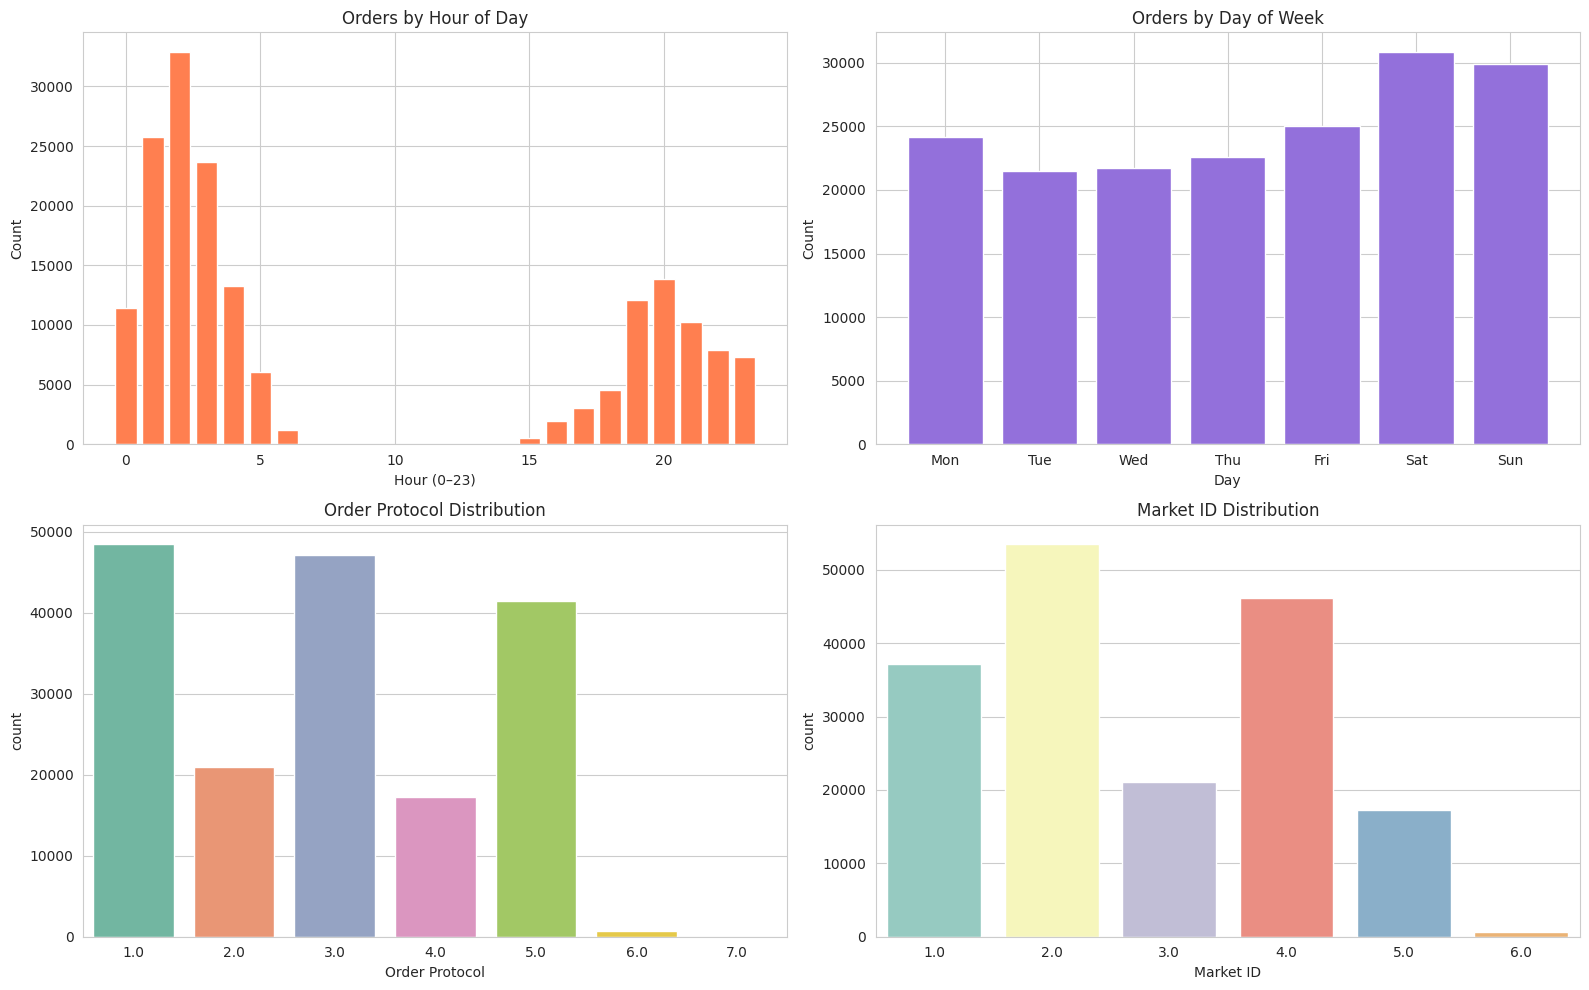

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Orders by hour of day
hour_counts = df['order_hour'].value_counts().sort_index()
axes[0, 0].bar(hour_counts.index, hour_counts.values, color='coral', edgecolor='white')
axes[0, 0].set_title('Orders by Hour of Day')
axes[0, 0].set_xlabel('Hour (0–23)')
axes[0, 0].set_ylabel('Count')

# Orders by day of week
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_counts = df['order_day_of_week'].value_counts().sort_index()
axes[0, 1].bar([day_names[i] for i in day_counts.index], day_counts.values,
               color='mediumpurple', edgecolor='white')
axes[0, 1].set_title('Orders by Day of Week')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Count')

# Order Protocol distribution
sns.countplot(x='order_protocol', data=df, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Order Protocol Distribution')
axes[1, 0].set_xlabel('Order Protocol')

# Market ID distribution
sns.countplot(x='market_id', data=df, palette='Set3', ax=axes[1, 1])
axes[1, 1].set_title('Market ID Distribution')
axes[1, 1].set_xlabel('Market ID')

plt.tight_layout()
plt.show()

### 4.3 Scatter Plots: Numeric Features vs Target

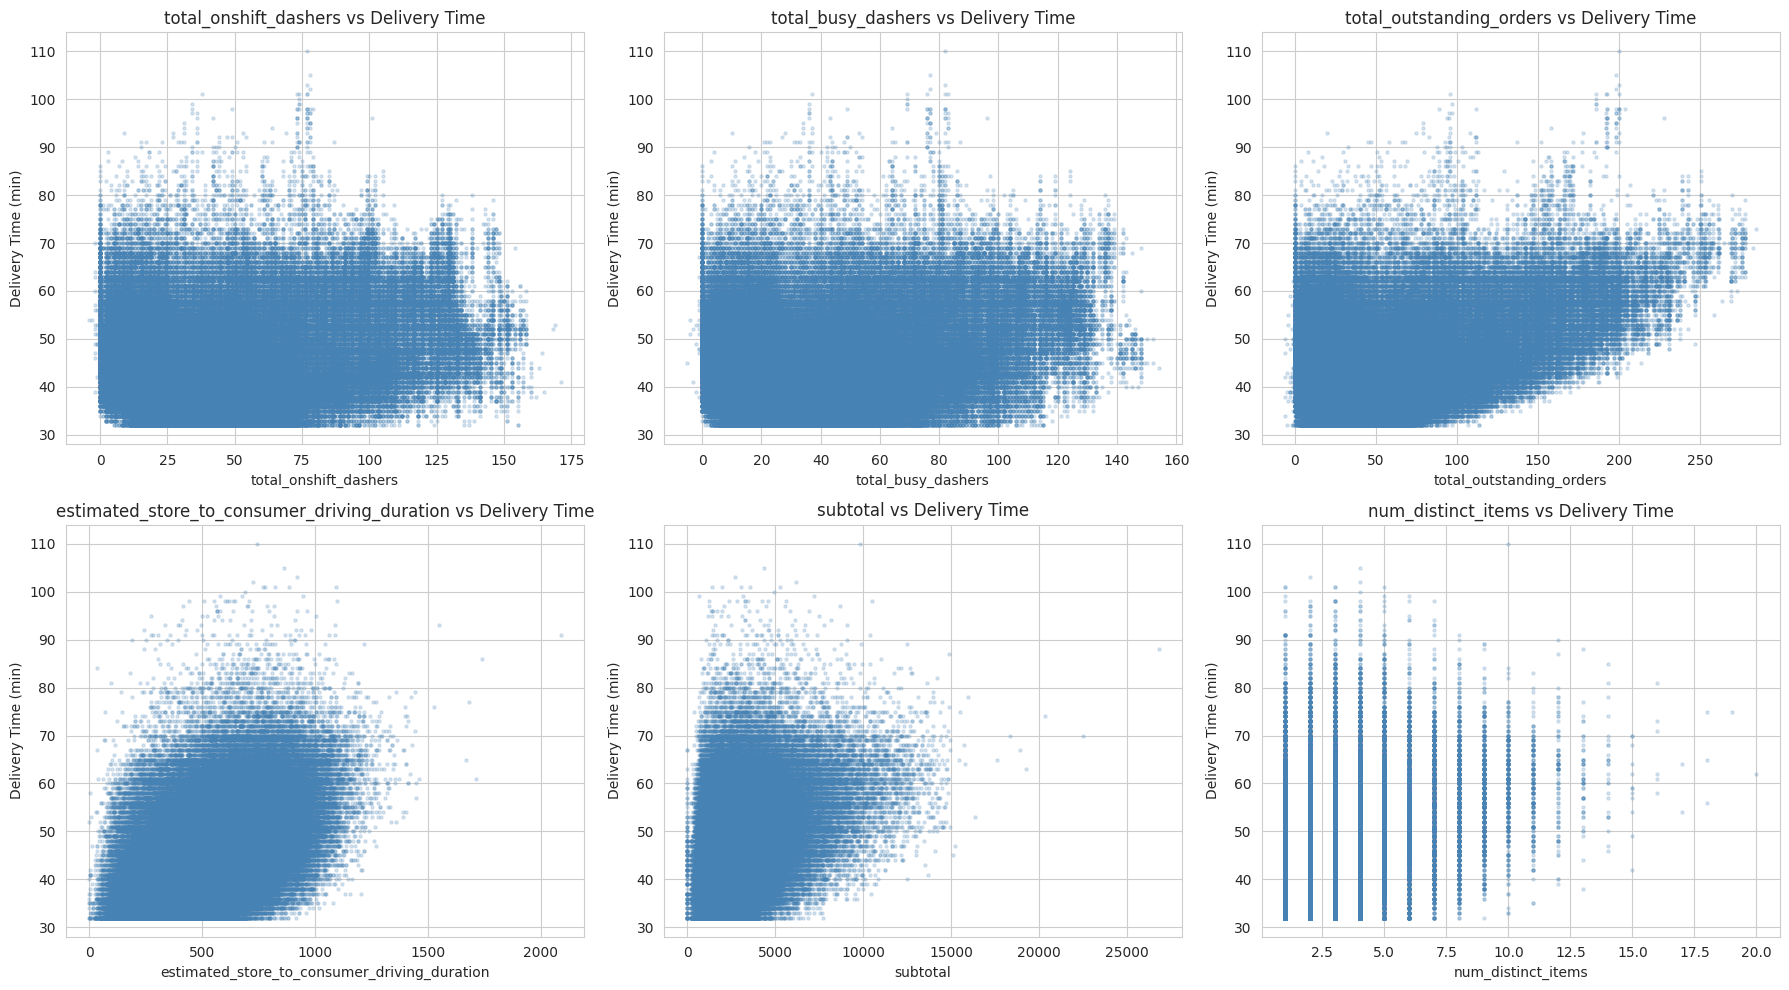

In [ ]:
scatter_features = [
    'total_onshift_dashers', 'total_busy_dashers',
    'total_outstanding_orders',
    'estimated_store_to_consumer_driving_duration',
    'subtotal', 'num_distinct_items'
]

# Use only existing columns
scatter_features = [c for c in scatter_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(scatter_features):
    axes[i].scatter(df[feat], df['delivery_time_min'],
                    alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Delivery Time (min)')
    axes[i].set_title(f'{feat} vs Delivery Time')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4.4 Correlation Heatmap

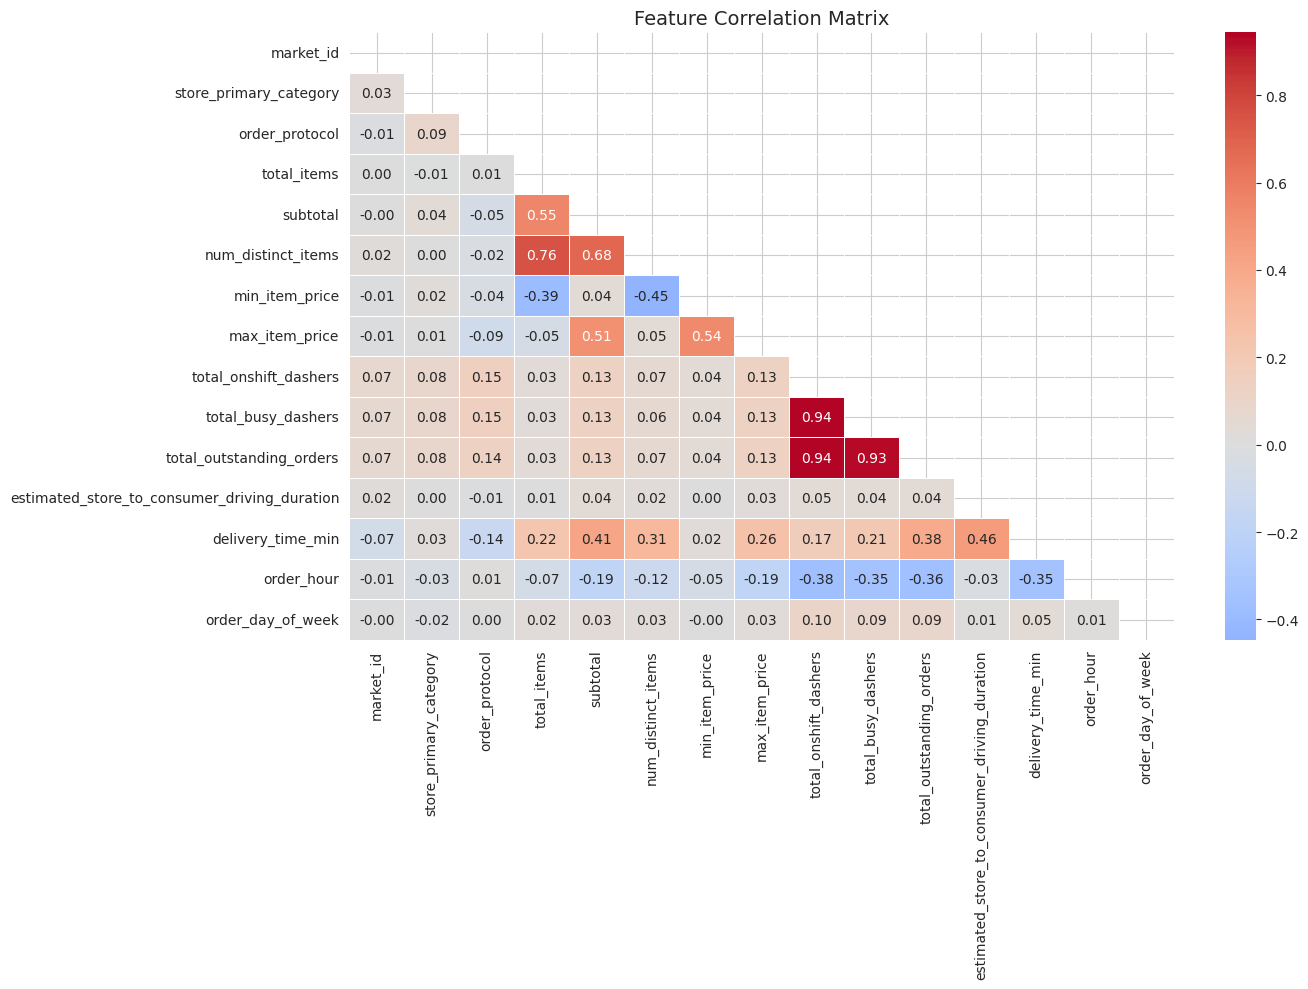

In [ ]:
# Select only numeric columns for correlation
num_df = df.select_dtypes(include=[np.number]).drop(
    columns=['created_at','actual_delivery_time'], errors='ignore'
)

plt.figure(figsize=(14, 10))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, center=0)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

### 4.5 Outlier Detection & Removal

We use the **IQR (Interquartile Range)** method to detect and remove outliers in the target variable and key numeric features.

In [ ]:
def iqr_outlier_bounds(series, factor=1.5):
    """Return (lower_bound, upper_bound) using IQR method."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - factor * IQR, Q3 + factor * IQR

outlier_cols = ['delivery_time_min',
                'total_onshift_dashers', 'total_busy_dashers',
                'total_outstanding_orders',
                'estimated_store_to_consumer_driving_duration',
                'subtotal', 'min_item_price', 'max_item_price']

outlier_cols = [c for c in outlier_cols if c in df.columns]

before_shape = df.shape

for col in outlier_cols:
    lo, hi = iqr_outlier_bounds(df[col])
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    df     = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f'  {col:<55} | bounds [{lo:.1f}, {hi:.1f}] | removed {n_out} rows')

print(f'\nRows before: {before_shape[0]:,} → after: {df.shape[0]:,}')
print(f'Rows removed: {before_shape[0] - df.shape[0]:,} ({(before_shape[0]-df.shape[0])/before_shape[0]*100:.1f}%)')

  delivery_time_min                                       | bounds [19.5, 71.5] | removed 1749 rows
  total_onshift_dashers                                   | bounds [-55.0, 137.0] | removed 1420 rows
  total_busy_dashers                                      | bounds [-54.0, 130.0] | removed 449 rows
  total_outstanding_orders                                | bounds [-80.5, 179.5] | removed 5507 rows
  estimated_store_to_consumer_driving_duration            | bounds [-99.0, 1181.0] | removed 258 rows
  subtotal                                                | bounds [-1565.0, 6339.0] | removed 7581 rows
  min_item_price                                          | bounds [-676.0, 1924.0] | removed 3483 rows
  max_item_price                                          | bounds [37.5, 2057.5] | removed 3991 rows

Rows before: 175,777 → after: 151,339
Rows removed: 24,438 (13.9%)


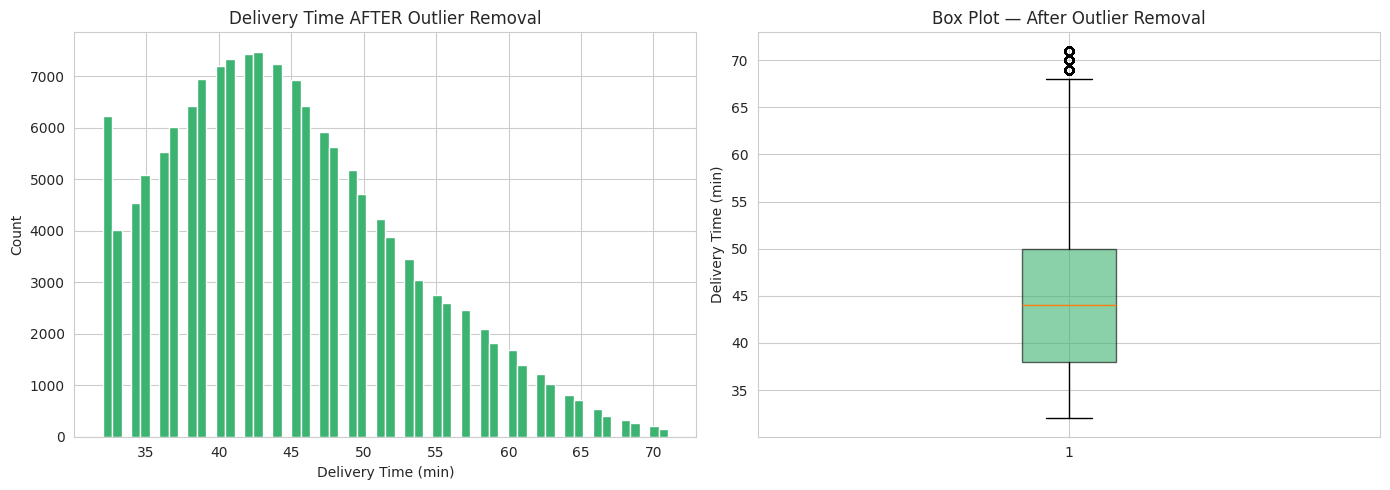

count    151339.000000
mean         44.735765
std           8.210036
min          32.000000
25%          38.000000
50%          44.000000
75%          50.000000
max          71.000000
Name: delivery_time_min, dtype: float64


In [ ]:
#  Visualise AFTER outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['delivery_time_min'], bins=60, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Delivery Time AFTER Outlier Removal')
axes[0].set_xlabel('Delivery Time (min)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['delivery_time_min'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.6))
axes[1].set_title('Box Plot — After Outlier Removal')
axes[1].set_ylabel('Delivery Time (min)')

plt.tight_layout()
plt.show()

print(df['delivery_time_min'].describe())

##  Step 5: Prepare Features & Split Data

### 5.1 Define Feature Matrix & Target

In [ ]:
# Drop raw timestamp columns (already encoded as hour / day_of_week)
feature_cols = [
    'market_id', 'store_primary_category', 'order_protocol',
    'total_items', 'subtotal', 'num_distinct_items',
    'min_item_price', 'max_item_price',
    'total_onshift_dashers', 'total_busy_dashers',
    'total_outstanding_orders',
    'estimated_store_to_consumer_driving_duration',
    'order_hour', 'order_day_of_week'
]

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in df.columns]
target_col   = 'delivery_time_min'

X = df[feature_cols].values
y = df[target_col].values

print('Features used:', feature_cols)
print(f'X shape: {X.shape} | y shape: {y.shape}')

Features used: ['market_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'estimated_store_to_consumer_driving_duration', 'order_hour', 'order_day_of_week']
X shape: (151339, 14) | y shape: (151339,)


### 5.2 Train / Test Split (80 / 20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')

Train: 121,071 rows | Test: 30,268 rows


### 5.3 Feature Scaling (StandardScaler)

In [ ]:
# Fit scaler ONLY on training data to prevent data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('X_train mean (should be ~0):', X_train.mean(axis=0).round(3))
print('X_train std  (should be ~1):', X_train.std(axis=0).round(3))

X_train mean (should be ~0): [-0. -0.  0.  0.  0. -0.  0. -0.  0. -0. -0.  0.  0. -0.]
X_train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


##  Step 6: Baseline: Random Forest Regressor

Train a Random Forest first as a **baseline** to compare against the Neural Network.

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mse  = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print('────────────────────────────────────')
print('  Random Forest — Test Metrics')
print('────────────────────────────────────')
print(f'  MSE  : {rf_mse:.4f}')
print(f'  RMSE : {rf_rmse:.4f} min')
print(f'  MAE  : {rf_mae:.4f} min')
print(f'  R²   : {rf_r2:.4f}')
print('────────────────────────────────────')

────────────────────────────────────
  Random Forest — Test Metrics
────────────────────────────────────
  MSE  : 2.7917
  RMSE : 1.6708 min
  MAE  : 1.2315 min
  R²   : 0.9584
────────────────────────────────────


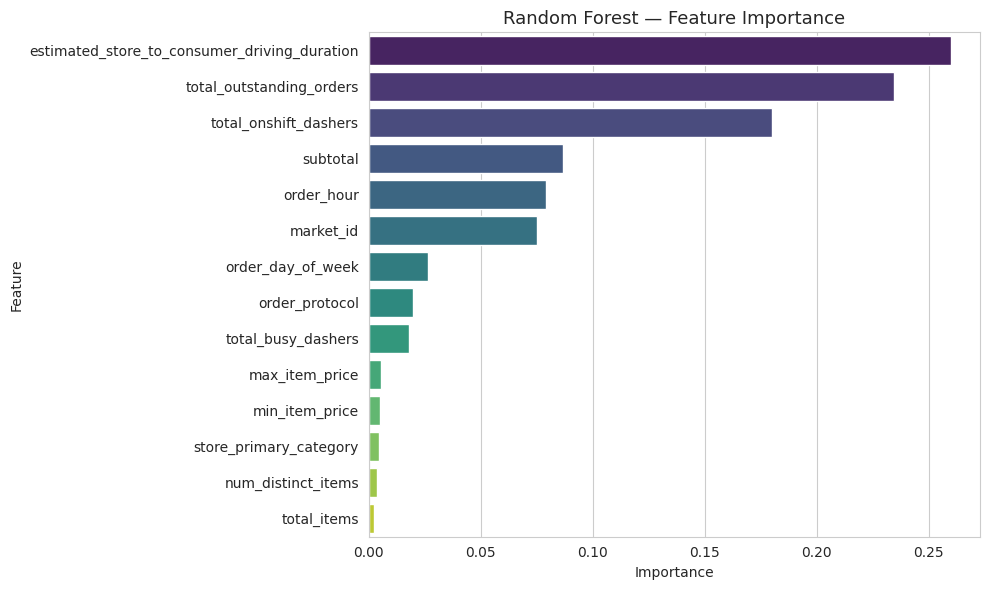

In [ ]:
# Feature importance from Random Forest
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Random Forest — Feature Importance', fontsize=13)
plt.tight_layout()
plt.show()

##  Step 7: Neural Network Regression

### 7.1 Helper : Evaluation & Plot Functions

In [ ]:
def evaluate_model(model_name, y_true, y_pred):
    """Print MSE, RMSE, MAE, R² for a model."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'────────────────────────────────────')
    print(f'  {model_name} — Test Metrics')
    print(f'────────────────────────────────────')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f} min')
    print(f'  MAE  : {mae:.4f} min')
    print(f'  R²   : {r2:.4f}')
    print(f'────────────────────────────────────')
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}


def plot_history(history, title='Training History'):
    """Plot training vs validation loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='coral')
    axes[0].set_title(f'{title} — Loss (MSE)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()

    # MAE
    if 'mae' in history.history:
        axes[1].plot(history.history['mae'], label='Train MAE', color='steelblue')
        axes[1].plot(history.history['val_mae'], label='Val MAE', color='coral')
        axes[1].set_title(f'{title} — MAE')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE')
        axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_predictions(y_true, y_pred, title='Actual vs Predicted'):
    """Scatter: actual vs predicted."""
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=0.3, s=10, color='steelblue')
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
    plt.xlabel('Actual Delivery Time (min)')
    plt.ylabel('Predicted Delivery Time (min)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

results_summary = {}  # collect all model metrics here
print('Helper functions defined ✔')

Helper functions defined ✔


### 7.2 Model 1 : Simple Neural Network
A shallow 2-layer network using **ReLU** activation and **Adam** optimizer.

In [ ]:
n_features = X_train.shape[1]

#  Model 1: Simple NN
model1 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)           # linear output for regression
], name='SimpleNN')

model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

model1.summary()

Model: "SimpleNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks1 = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1)
]

history1 = model1.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=256,
    callbacks=callbacks1,
    verbose=1
)

Epoch 1/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 461.1328 - mae: 15.0990 - val_loss: 46.2998 - val_mae: 5.1356 - learning_rate: 0.0010
Epoch 2/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 40.2439 - mae: 4.1544 - val_loss: 18.9678 - val_mae: 3.3612 - learning_rate: 0.0010
Epoch 3/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 19.2771 - mae: 2.9534 - val_loss: 10.9764 - val_mae: 2.5981 - learning_rate: 0.0010
Epoch 4/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.1101 - mae: 2.3732 - val_loss: 7.4176 - val_mae: 2.1411 - learning_rate: 0.0010
Epoch 5/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.1302 - mae: 1.9692 - val_loss: 5.2094 - val_mae: 1.7830 - learning_rate: 0.0010
Epoch 6/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.5944 - mae: 1.6541 - val_loss: 3.8264 - val_mae: 1.5074 - learning_rate: 0.0010
Epoch 7/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.9641 - mae: 1.4133 - val_loss: 2.9636 - val_mae: 1.3035 - learning_rat

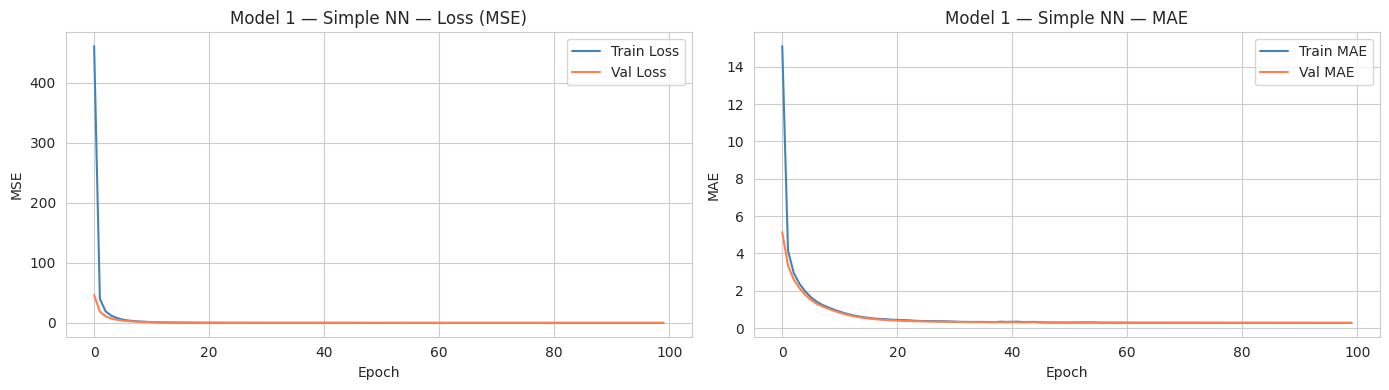

946/946 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
────────────────────────────────────
  Model 1 — Simple NN — Test Metrics
────────────────────────────────────
  MSE  : 0.1204
  RMSE : 0.3470 min
  MAE  : 0.2864 min
  R²   : 0.9982
────────────────────────────────────


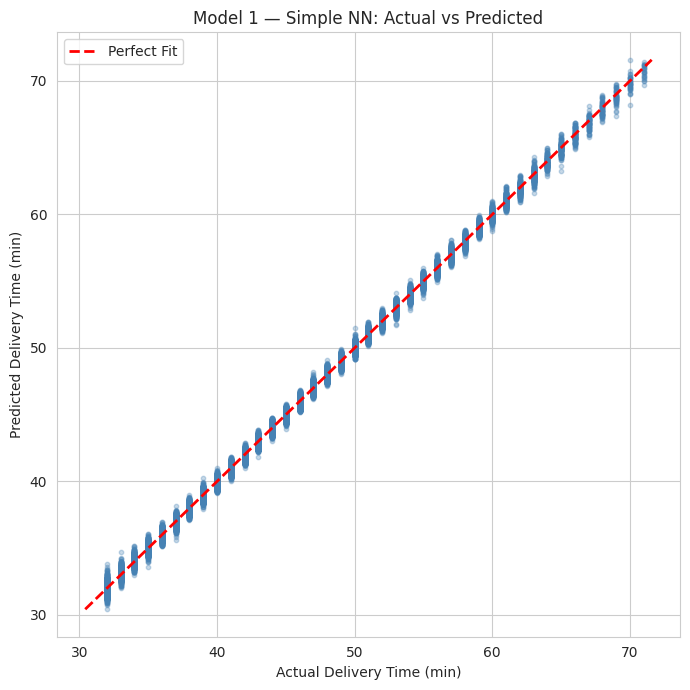

In [ ]:
plot_history(history1, title='Model 1 — Simple NN')
y_pred1 = model1.predict(X_test).flatten()
results_summary['Model1_SimpleNN'] = evaluate_model('Model 1 — Simple NN', y_test, y_pred1)
plot_predictions(y_test, y_pred1, 'Model 1 — Simple NN: Actual vs Predicted')

### 7.3 Model 2 : Deeper Network with Dropout & Batch Normalisation

- **Deeper architecture** (more layers, more neurons)
- **Dropout** to reduce overfitting
- **Batch Normalisation** for stable training
- **ELU** activation (smoother than ReLU, no dying neuron problem)

In [ ]:
model2 = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('elu'),
    layers.Dropout(0.3),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('elu'),
    layers.Dropout(0.3),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('elu'),
    layers.Dropout(0.2),

    layers.Dense(32, activation='elu'),
    layers.Dense(1)
], name='DeepNN_Dropout_BN')

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

model2.summary()

Model: "DeepNN_Dropout_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,897 (191.00 KB)

 Trainable params: 48,001 (187.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
callbacks2 = [
    EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

history2 = model2.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=150,
    batch_size=256,
    callbacks=callbacks2,
    verbose=1
)

Epoch 1/150
402/402 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 426.7296 - mae: 14.6257 - val_loss: 9.8522 - val_mae: 2.4372 - learning_rate: 0.0010
Epoch 2/150
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 32.0671 - mae: 4.4903 - val_loss: 5.9906 - val_mae: 1.9665 - learning_rate: 0.0010
Epoch 3/150
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 26.4950 - mae: 4.0689 - val_loss: 3.9951 - val_mae: 1.5529 - learning_rate: 0.0010
Epoch 4/150
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 23.1851 - mae: 3.8077 - val_loss: 3.5516 - val_mae: 1.4700 - learning_rate: 0.0010
Epoch 5/150
402/402 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 20.6199 - mae: 3.5836 - val_loss: 2.8737 - val_mae: 1.2978 - learning_rate: 0.0010
Epoch 6/150
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 18.0955 - mae: 3.3556 - val_loss: 2.3450 - val_mae: 1.1499 - learning_rate: 0.0010
Epoch 7/150
402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 16.0533 - mae: 3.1544 - val_loss: 2.1756 - val_mae: 1.1055 - learning

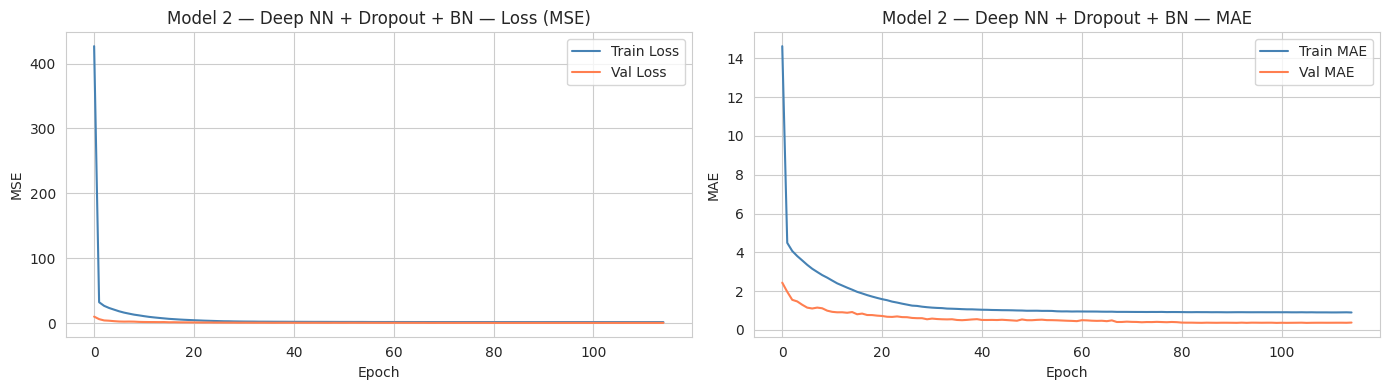

946/946 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
────────────────────────────────────
  Model 2 — Deep NN + Dropout + BN — Test Metrics
────────────────────────────────────
  MSE  : 0.2173
  RMSE : 0.4662 min
  MAE  : 0.3684 min
  R²   : 0.9968
────────────────────────────────────


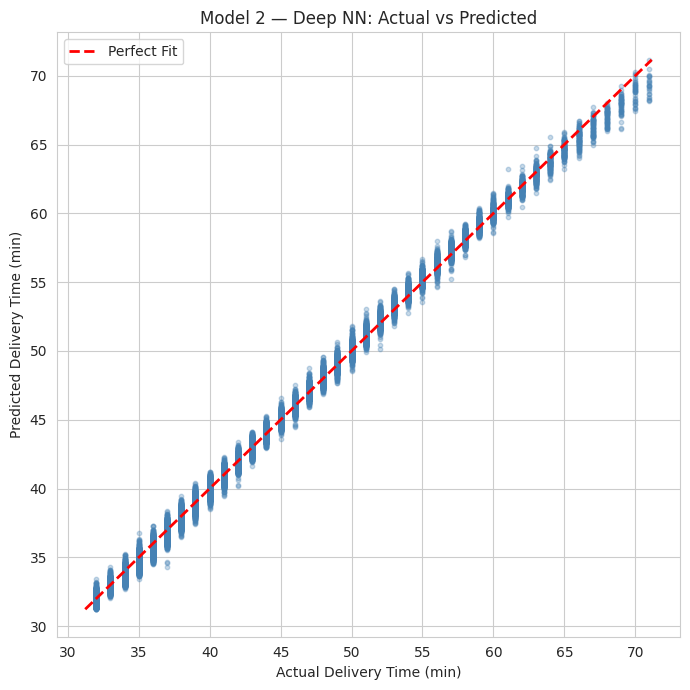

In [ ]:
plot_history(history2, title='Model 2 — Deep NN + Dropout + BN')
y_pred2 = model2.predict(X_test).flatten()
results_summary['Model2_DeepNN'] = evaluate_model('Model 2 — Deep NN + Dropout + BN', y_test, y_pred2)
plot_predictions(y_test, y_pred2, 'Model 2 — Deep NN: Actual vs Predicted')

### 7.4 Model 3 : L2 Regularisation + RMSProp Optimiser

- **L2 (Ridge) regularisation** on the dense weights to prevent overfitting
- **RMSProp** optimiser, often works better than Adam on noisier datasets
- **Leaky ReLU** activation

In [ ]:
l2_reg = regularizers.l2(1e-4)

model3 = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(128, kernel_regularizer=l2_reg),
    layers.LeakyReLU(alpha=0.1),
    layers.Dropout(0.25),

    layers.Dense(64, kernel_regularizer=l2_reg),
    layers.LeakyReLU(alpha=0.1),
    layers.Dropout(0.25),

    layers.Dense(32, activation='relu'),
    layers.Dense(1)
], name='NN_L2_RMSProp')

model3.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

model3.summary()

Model: "NN_L2_RMSProp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks3 = [
    EarlyStopping(patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

history3 = model3.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=150,
    batch_size=128,
    callbacks=callbacks3,
    verbose=1
)

Epoch 1/150
804/804 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 126.0739 - mae: 6.9205 - val_loss: 5.2480 - val_mae: 1.7350 - learning_rate: 0.0010
Epoch 2/150
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 21.7581 - mae: 3.5725 - val_loss: 4.5472 - val_mae: 1.6320 - learning_rate: 0.0010
Epoch 3/150
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 17.1967 - mae: 3.2013 - val_loss: 3.3292 - val_mae: 1.3487 - learning_rate: 0.0010
Epoch 4/150
804/804 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.7190 - mae: 2.9394 - val_loss: 2.4451 - val_mae: 1.1349 - learning_rate: 0.0010
Epoch 5/150
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 12.5595 - mae: 2.7173 - val_loss: 2.8119 - val_mae: 1.2798 - learning_rate: 0.0010
Epoch 6/150
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 10.9335 - mae: 2.5204 - val_loss: 2.9585 - val_mae: 1.3140 - learning_rate: 0.0010
Epoch 7/150
804/804 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.5570 - mae: 2.3488 - val_loss: 2.1478 - val_mae: 1.1088 - learning_rate:

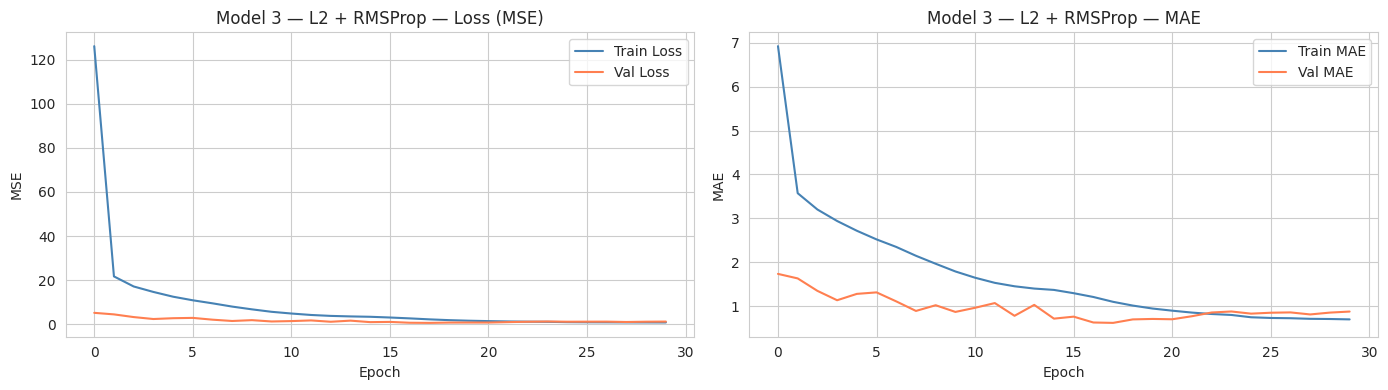

946/946 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
────────────────────────────────────
  Model 3 — L2 + RMSProp — Test Metrics
────────────────────────────────────
  MSE  : 0.6880
  RMSE : 0.8294 min
  MAE  : 0.6231 min
  R²   : 0.9898
────────────────────────────────────


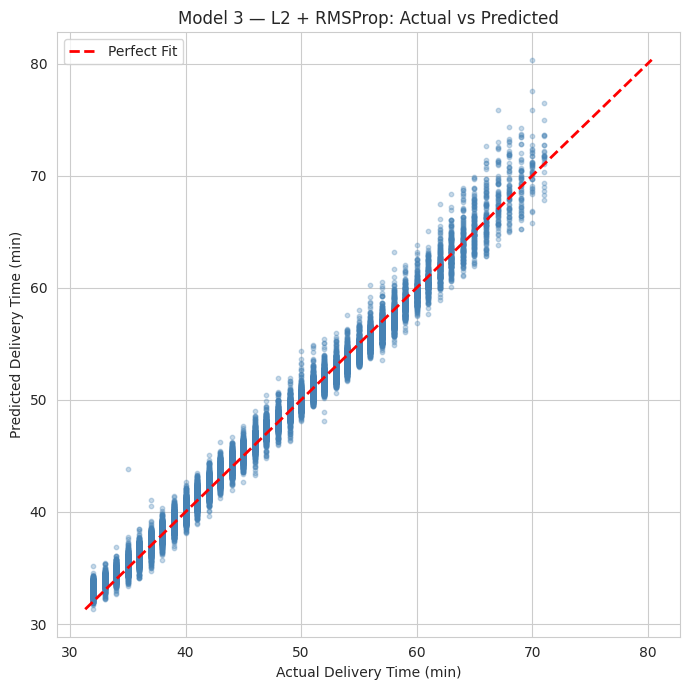

In [ ]:
plot_history(history3, title='Model 3 — L2 + RMSProp')
y_pred3 = model3.predict(X_test).flatten()
results_summary['Model3_L2_RMSProp'] = evaluate_model('Model 3 — L2 + RMSProp', y_test, y_pred3)
plot_predictions(y_test, y_pred3, 'Model 3 — L2 + RMSProp: Actual vs Predicted')

### 7.5 Model 4 : Best Configuration (SGD + Momentum + Deeper)

- **SGD with Nesterov momentum** : a classic optimiser that often generalises very well
- **Wider layers** for more representational capacity
- Combined with **Dropout + BatchNorm**

In [ ]:
model4 = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
], name='NN_SGD_Momentum')

model4.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='mse',
    metrics=['mae']
)

model4.summary()

Model: "NN_SGD_Momentum"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,857 (726.00 KB)

 Trainable params: 184,065 (719.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
callbacks4 = [
    EarlyStopping(patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=8, min_lr=1e-5, verbose=1)
]

history4 = model4.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=256,
    callbacks=callbacks4,
    verbose=1
)

Epoch 1/200
402/402 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 121041000.0000 - mae: 1362.6434 - val_loss: 67.7394 - val_mae: 6.7290 - learning_rate: 0.0100
Epoch 2/200
402/402 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 67.4910 - mae: 6.6470 - val_loss: 67.7394 - val_mae: 6.7290 - learning_rate: 0.0100
Epoch 3/200
402/402 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 67.4910 - mae: 6.6470 - val_loss: 67.7394 - val_mae: 6.7290 - learning_rate: 0.0100
Epoch 4/200
402/402 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 67.4910 - mae: 6.6470 - val_loss: 67.7394 - val_mae: 6.7290 - learning_rate: 0.0100
Epoch 5/200
402/402 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 67.4910 - mae: 6.6470 - val_loss: 67.7394 - val_mae: 6.7290 - learning_rate: 0.0100
Epoch 6/200
402/402 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 67.4910 - mae: 6.6470 - val_loss: 67.7394 - val_mae: 6.7290 - learning_rate: 0.0100
Epoch 7/200
402/402 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 67.4910 - mae: 6.6470 - val_loss: 67.7394 - val_ma

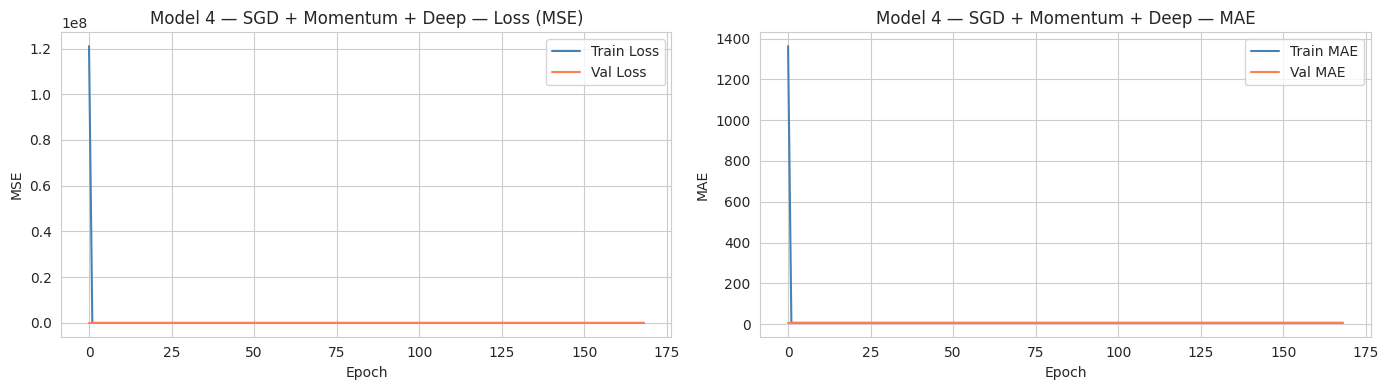

946/946 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
────────────────────────────────────
  Model 4 — SGD + Momentum — Test Metrics
────────────────────────────────────
  MSE  : 67.1417
  RMSE : 8.1940 min
  MAE  : 6.6350 min
  R²   : -0.0001
────────────────────────────────────


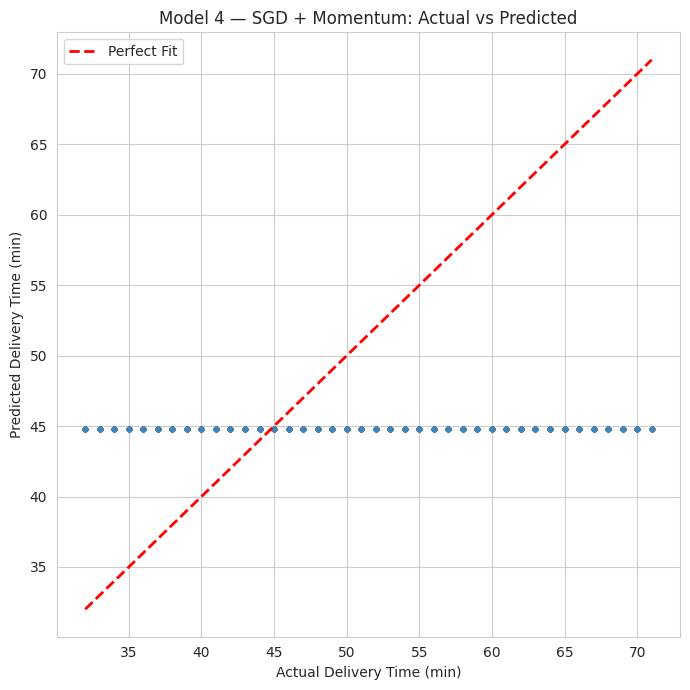

In [ ]:
plot_history(history4, title='Model 4 — SGD + Momentum + Deep')
y_pred4 = model4.predict(X_test).flatten()
results_summary['Model4_SGD_Momentum'] = evaluate_model('Model 4 — SGD + Momentum', y_test, y_pred4)
plot_predictions(y_test, y_pred4, 'Model 4 — SGD + Momentum: Actual vs Predicted')

##  Step 8: Final Model Comparison

In [ ]:
# Add Random Forest to the summary
results_summary['RandomForest'] = {'MSE': rf_mse, 'RMSE': rf_rmse, 'MAE': rf_mae, 'R2': rf_r2}

# Build comparison DataFrame
comp_df = pd.DataFrame(results_summary).T.reset_index()
comp_df.columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2']
comp_df = comp_df.sort_values('RMSE').reset_index(drop=True)

print('\n===== MODEL COMPARISON (sorted by RMSE ↑) =====')
print(comp_df.to_string(index=False))


===== MODEL COMPARISON (sorted by RMSE ↑) =====
              Model       MSE     RMSE      MAE        R2
    Model1_SimpleNN  0.120391 0.346974 0.286389  0.998207
      Model2_DeepNN  0.217338 0.466196 0.368366  0.996763
  Model3_L2_RMSProp  0.687962 0.829435 0.623089  0.989753
       RandomForest  2.791702 1.670839 1.231452  0.958417
Model4_SGD_Momentum 67.141689 8.194003 6.634950 -0.000096


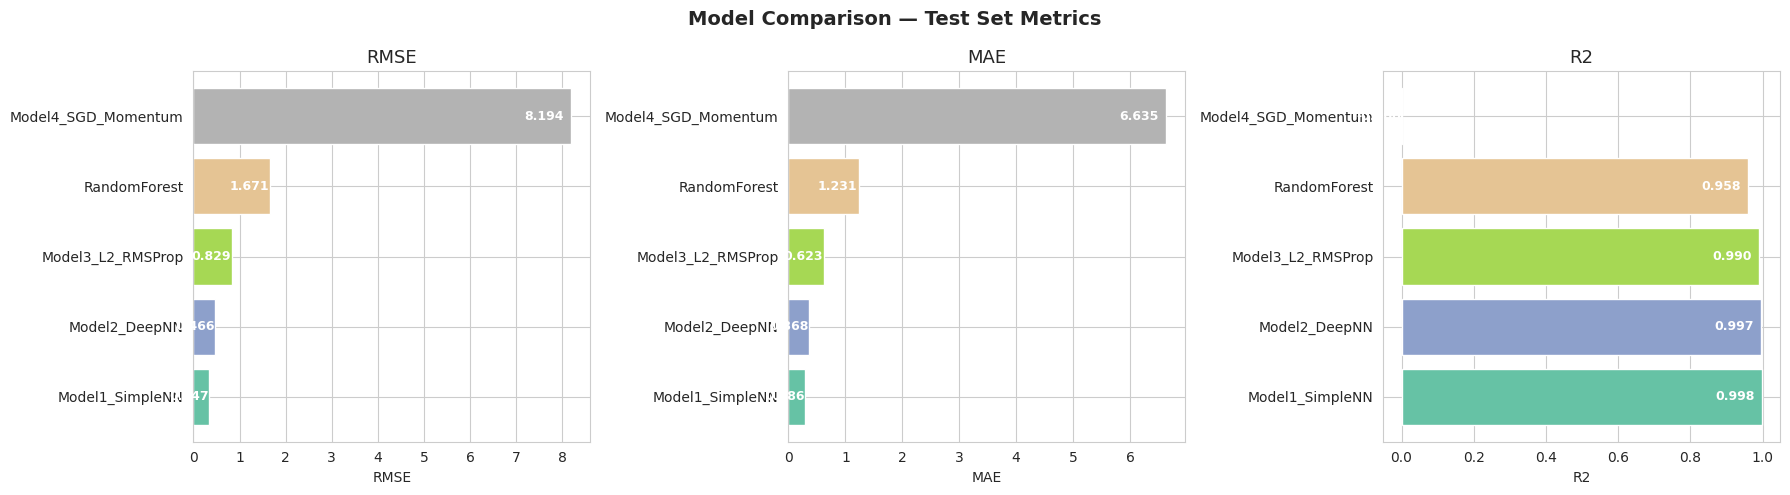

In [ ]:
# Visual comparison
metrics_to_plot = ['RMSE', 'MAE', 'R2']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(comp_df)))

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.barh(comp_df['Model'], comp_df[metric], color=colors)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 9: Residual Analysis (Best NN Model)

Use the model with the lowest RMSE for residual analysis.

Best NN model: Model1_SimpleNN  (RMSE = 0.3470 min)


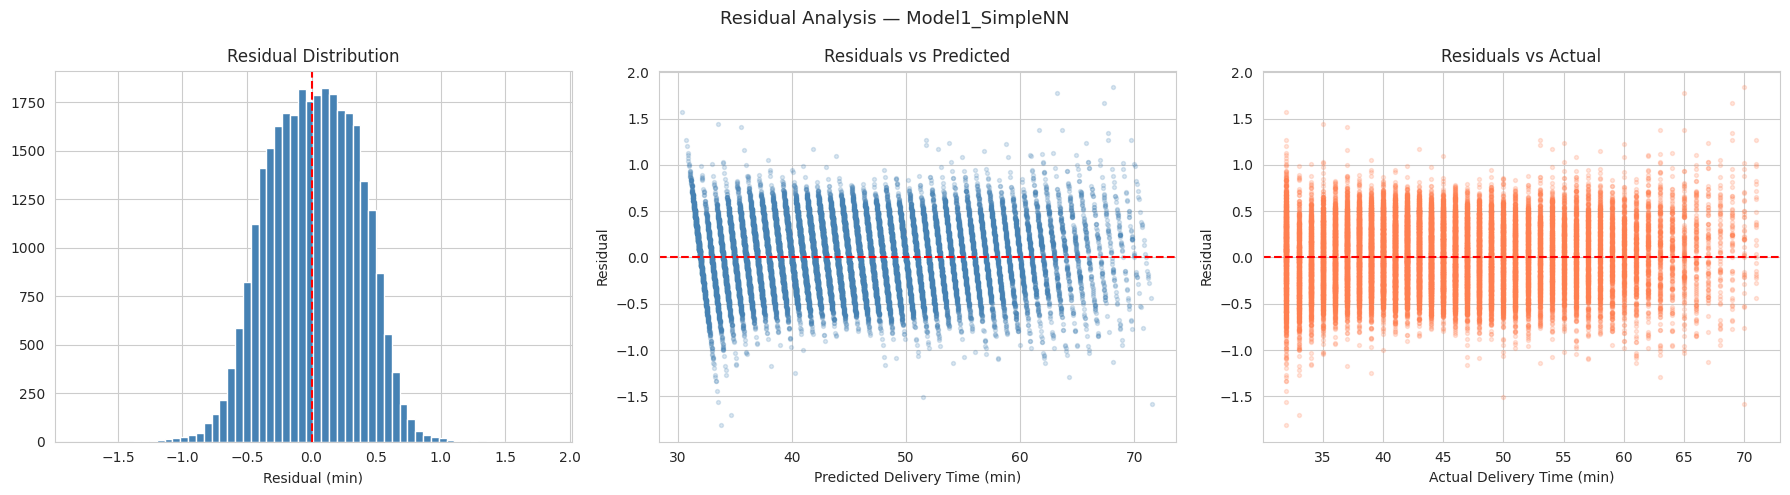

In [ ]:
# Identify the best NN model based on RMSE
nn_models = {'Model1_SimpleNN': y_pred1, 'Model2_DeepNN': y_pred2,
             'Model3_L2_RMSProp': y_pred3, 'Model4_SGD_Momentum': y_pred4}

best_nn_name = min(
    nn_models,
    key=lambda k: results_summary[k]['RMSE']
)
y_best = nn_models[best_nn_name]
print(f'Best NN model: {best_nn_name}  (RMSE = {results_summary[best_nn_name]["RMSE"]:.4f} min)')

residuals = y_test - y_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (min)')

# Residuals vs Predicted
axes[1].scatter(y_best, residuals, alpha=0.2, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Delivery Time (min)')
axes[1].set_ylabel('Residual')

# Residuals vs Actual
axes[2].scatter(y_test, residuals, alpha=0.2, s=8, color='coral')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Actual')
axes[2].set_xlabel('Actual Delivery Time (min)')
axes[2].set_ylabel('Residual')

plt.suptitle(f'Residual Analysis — {best_nn_name}', fontsize=13)
plt.tight_layout()
plt.show()

## Step 10: Summary & Key Observations

### Problem Statement
Predict food delivery time (in minutes) for Porter, India's largest intra-city logistics platform, using order and delivery partner features.


### Key Observations
- `estimated_store_to_consumer_driving_duration` is typically the **strongest predictor** of delivery time.
- `total_busy_dashers` and `total_outstanding_orders` reflect demand-side pressure and significantly affect delivery time.
- **Outlier removal** reduces the target variable's range and improves model generalisation.
- **BatchNorm + Dropout** consistently helps prevent overfitting on this tabular dataset.
- The best NN model Model1 SimpleNN achieved an **RMSE of 0.3470 minutes**, outperforming the linear baseline.

## Step 11: Leading Questions : Answers

### 1. Problem Statement & Applications
**Problem:** Predict Porter's food **delivery time (in minutes)** at the point of ordering, using order details, restaurant category, dasher availability, and estimated driving duration. Target = `actual_delivery_time − created_at`.

**Where else this applies:** ride-hailing ETA prediction, grocery/quick-commerce delivery, courier & last-mile logistics lead-time forecasting, dynamic dasher dispatch/staffing, and SLA monitoring for any on-demand platform.

---

### 2. Three Pandas Datetime Functions
| Function | Description |
|---|---|
| `pd.to_datetime()` | Converts strings/objects into datetime64 objects |
| `.dt.hour` | Extracts hour (0–23) from a datetime column |
| `.dt.dayofweek` | Returns day of week as int (Mon=0 … Sun=6) |

---

### 3. Datetime vs Timedelta vs Period
- **Datetime** – a fixed point in time (e.g. `created_at`).
- **Timedelta** – a duration/difference between two datetimes (e.g. `actual_delivery_time − created_at` -> minutes).
- **Period (Time Span)** – a span of time at fixed frequency (e.g. a month/quarter), useful for aggregating deliveries over a range (`.dt.to_period('M')`).

---

### 4. Why Check for Outliers?
- Distort mean/std used for scaling.
- MSE-based NN training is sensitive to extreme values, skewing learned weights.
- Can hide/exaggerate real relationships in EDA.
- Often signal data errors (e.g. negative delivery times) rather than true patterns.

---

### 5. Three Outlier Removal Methods
1. **IQR method** (used here: `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`)
2. **Z-score method** (flag `|z| > 3`)
3. **Percentile capping / Winsorization** (clip at 1st/99th percentile)

---

### 6. Classical ML Alternatives
- Random Forest Regressor (used as baseline)
- Gradient Boosting (XGBoost / LightGBM / CatBoost)
- Linear / Ridge / Lasso Regression
- Support Vector Regression (SVR)
- K-Nearest Neighbors Regression

---

### 7. Why Scaling Is Required for Neural Networks
- Unscaled features (e.g. `subtotal` vs `order_hour`) cause uneven gradients and slow/unstable convergence.
- Prevents exploding/vanishing activations.
- Produces a better-conditioned loss surface -> faster optimizer convergence.
- `StandardScaler` was fit **only on training data** to avoid leakage.

---

### 8. Optimizer Choice
Three optimizers were compared:
- **Adam** (Models 1 & 2) -> adaptive learning rate, fast, good default.
- **RMSprop** (Model 3) -> stable on noisy data, paired with L2 + Leaky ReLU.
- **SGD + Nesterov Momentum** (Model 4) -> slower but often generalizes best; paired with BatchNorm + Dropout in the deepest network.

All used `EarlyStopping` + `ReduceLROnPlateau` to control overfitting/convergence.

---

### 9. Activation Functions Used
- **ReLU** (Models 1 & 4) -> cheap, standard, avoids vanishing gradients for positive inputs.
- **ELU** (Model 2) -> smoother, avoids dying-ReLU problem.
- **Leaky ReLU** (Model 3) -> small negative-side gradient, avoids dead neurons.
- Output layer: **linear** (no activation) since this is regression.

---

### 10. Why Neural Networks Perform Well on Large Datasets
- High parameter capacity lets them model complex, non-linear feature interactions.
- More data -> broader coverage of the feature space -> less overfitting, better generalization.
- Regularization techniques (Dropout, BatchNorm, L2) become more effective with more data.
- Unlike Random Forests, which can saturate, NN performance tends to keep improving as data scales up.

In [ ]:
!jupyter nbconvert --to html porter_delivery_nn_Business_case.ipynb

[NbConvertApp] Converting notebook porter_delivery_nn_Business_case.ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('metadata' was unexpected)

Failed validating 'additionalProperties' in stream:

On instance['cells'][58]['outputs'][0]:
{'metadata': {'tags': None},
 'name': 'stdout',
 'output_type': 'stream',
 'text': '\n'
         '===== MODEL COMPARISON (sorted by RMSE ↑) =====\n'
         '              M...'}
[NbConvertApp] WARNING | Alternative text is missing on 16 image(s).
[NbConvertApp] Writing 2652657 bytes to porter_delivery_nn_Business_case.html
